# KNN Anomaly Detection

This notebook uses a **K-Nearest Neighbors (KNN)** approach to detect anomalies in spectra data.

**Core idea:**
- Train KNN on `all_spectra.csv` — these are the "normal" particles the model learns from
- For any new sample, compute its distance to its K nearest neighbors in the training set
- A **high average distance** means the sample looks nothing like the normal particles → flagged as an anomaly
- A **low average distance** means the sample closely resembles normal particles → classified as normal

**Goal:** Evaluate whether the model can correctly identify `ambient_spectra.csv` particles as anomalies.

## 1. Hyperparameters

All the settings you can tune are collected here in one place so you don't have to hunt through the code to change them.

| Parameter | Description |
|-----------|-------------|
| `N_NEIGHBORS` | How many nearest neighbors to look at. Higher K = smoother decision boundary but less sensitive to local anomalies |
| `METRIC` | How distance between two spectra is measured. Try `'euclidean'`, `'manhattan'`, or `'cosine'` |
| `THRESHOLD_PERCENTILE` | The anomaly score cutoff. Scores above this percentile (computed on training data) are flagged as anomalies. E.g. 95 means the top 5% most unusual training samples set the bar |

In [56]:
# ── Tune these values to experiment with the model ──────────────────────────

N_NEIGHBORS = 5           # number of nearest neighbors (K)
METRIC = 'euclidean'      # distance metric: 'euclidean', 'manhattan', or 'cosine'
THRESHOLD_PERCENTILE = 95 # percentile of training anomaly scores used as the decision threshold

# ─────────────────────────────────────────────────────────────────────────────

## 2. Imports

Loading all the libraries needed for data handling, the KNN model, evaluation metrics, and plotting.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors          # KNN model
from sklearn.metrics import (                           # evaluation tools
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 3. Load Data

- `all_spectra.csv` → **normal** particles. The model trains exclusively on these.
- `ambient_spectra.csv` → **anomaly** particles. These are only used at evaluation time — the model never sees them during training.

Only the wavelength intensity columns are used as features. The `polymer` label column is dropped from the feature matrix.

In [58]:
# Load both datasets; the unnamed first column is the row index
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Identify the label column and keep only wavelength columns as features
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices — rows = samples, columns = wavelength intensities
X_normal  = all_spectra[wavelengths].values      # shape: (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # shape: (55, 535)

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')
print(f'Features (wavelengths): {X_normal.shape[1]}')

Normal samples  : (1215, 535)
Anomaly samples : (55, 535)
Features (wavelengths): 535


In [59]:
# Debugging purposes to visualize X_normal feature matrix
print(X_normal)

[[-0.44703525 -0.42126636 -0.46783553 ... -0.51459458 -0.28045798
  -0.34772283]
 [-0.81508477 -0.51245584 -0.29787366 ... -0.61404614  0.06599976
   0.13480674]
 [-0.52071023 -0.44501742 -0.35265573 ... -0.56980478 -0.79810188
  -0.83836917]
 ...
 [-0.32537894 -0.55109025 -0.5117551  ... -4.92360419 -2.44458897
   2.7211019 ]
 [-0.35477403 -0.32105978 -0.46126666 ... -0.25180213 -0.58757771
  -0.77534183]
 [-0.32740481 -0.39403687 -0.72885283 ...  0.37809285  1.62293095
   0.98478098]]


In [60]:
# Debugging purposes to visualize X_anomaly feature matrix
print(X_anomaly)

[[-0.25103157  0.05708775  0.3262619  ... -1.9996534  -2.29355257
  -2.9627264 ]
 [-0.19345265 -0.13223257 -0.07401238 ... -0.32952997 -0.39097813
  -0.44459355]
 [ 0.05846988  0.19509357  0.35123658 ... -1.16562231 -1.33772469
  -1.5047268 ]
 ...
 [-0.65336412 -0.10091108  0.0744781  ... -3.08461005 -4.16325468
  -3.95608807]
 [-0.62941658 -1.13178565 -1.25222691 ... -0.63771735 -1.59406505
  -0.48052663]
 [-0.24663933 -0.23894368 -0.24871615 ... -0.91115839 -0.89654493
  -0.65416932]]


## 4. Train KNN

`NearestNeighbors` is used here instead of `KNeighborsClassifier` because this is **unsupervised anomaly detection** — the model is never given any labels. It simply memorizes the normal samples and later measures how far any new sample is from them.

Training is instant: the model just stores the normal data points.

In [61]:
# Build and fit the KNN model on normal samples only
knn = NearestNeighbors(n_neighbors=N_NEIGHBORS, metric=METRIC)
knn.fit(X_normal)

print(f'KNN model trained on {X_normal.shape[0]} normal samples')
print(f'K = {N_NEIGHBORS}, metric = {METRIC}')

KNN model trained on 1215 normal samples
K = 5, metric = euclidean


## 5. Compute Anomaly Scores

For each sample, the **anomaly score** is the mean distance to its K nearest neighbors in the training set.

- A **low score** → the sample sits close to normal particles → likely normal
- A **high score** → the sample is far from all normal particles → likely an anomaly

Scores are computed for both the normal samples (to set the threshold) and the ambient samples (to evaluate).

In [62]:
# Compute distances to K nearest neighbors for normal training samples
# distances shape: (n_samples, K) — one distance per neighbor
distances_normal, _ = knn.kneighbors(X_normal)

# Compute distances for ambient (anomaly) samples
distances_anomaly, _ = knn.kneighbors(X_anomaly)

# Anomaly score = mean distance across the K neighbors for each sample
scores_normal  = distances_normal.mean(axis=1)   # shape: (1215,)
scores_anomaly = distances_anomaly.mean(axis=1)  # shape: (55,)

print(f'Normal  scores — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Anomaly scores — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

Normal  scores — min: 0.6717  max: 23.8926  mean: 6.2638
Anomaly scores — min: 6.6808  max: 23.5473  mean: 14.9361


In [70]:
# Debugging purposes - print the distances to the 5 nearest neighbors in normal dataset for each polymer
print("===DISTANCE TO 5 NEAREST NEIGHBOR FOR EACH POLYMER===")
print(distances_normal)
print(distances_normal.shape)

print("===ANOMALY SCORE (MEAN DISTANCE TO 5 NEAREST NEIGHBOR FOR EACH POLYMER)===")
print(scores_normal)
print(scores_normal.shape)

===DISTANCE TO 5 NEAREST NEIGHBOR FOR EACH POLYMER===
[[4.76837158e-07 4.17902244e+00 4.46598991e+00 4.76115891e+00
  4.85833150e+00]
 [0.00000000e+00 3.85311504e+00 4.15739004e+00 4.61670761e+00
  4.85833150e+00]
 [0.00000000e+00 4.08840543e+00 4.52943590e+00 4.59934778e+00
  4.62906617e+00]
 ...
 [0.00000000e+00 1.50375428e+01 1.52474435e+01 1.53079236e+01
  1.53278143e+01]
 [8.25906185e-07 5.22015837e+00 5.38849294e+00 5.58502165e+00
  5.59384923e+00]
 [0.00000000e+00 9.63960567e+00 9.68748297e+00 1.00007153e+01
  1.02086228e+01]]
(1215, 5)
===ANOMALY SCORE (MEAN DISTANCE TO 5 NEAREST NEIGHBOR FOR EACH POLYMER)===
[ 3.65290065  3.49710884  3.56925105 ... 12.18414483  4.3575046
  7.90728535]
(1215,)


## 6. Set Decision Threshold

The threshold is the score above which a sample is declared an anomaly. It is set using a percentile of the **normal training scores** — meaning the model decides what "unusually far" looks like based on the normal data itself.

- `THRESHOLD_PERCENTILE = 95` → the top 5% most distant normal samples set the bar. Anything above this is flagged as an anomaly.
- **Raising** the percentile makes the model more lenient (fewer anomaly detections).
- **Lowering** the percentile makes the model more aggressive (more anomaly detections, but more false positives).

In [64]:
# Set the threshold as the chosen percentile of normal sample scores
threshold = np.percentile(scores_normal, THRESHOLD_PERCENTILE)

print(f'Threshold (p{THRESHOLD_PERCENTILE} of normal scores): {threshold:.4f}')
print(f'Any sample with an anomaly score above {threshold:.4f} will be flagged as an anomaly')

Threshold (p95 of normal scores): 19.2849
Any sample with an anomaly score above 19.2849 will be flagged as an anomaly


## 7. Anomaly Score Distribution

Plotting the anomaly score distributions for both normal and ambient samples side by side. The vertical red dashed line marks the decision threshold.

**What to look for:**
- If the two distributions are well separated, the model is clearly distinguishing normal from anomalous samples
- If they overlap heavily, the model is struggling to tell them apart

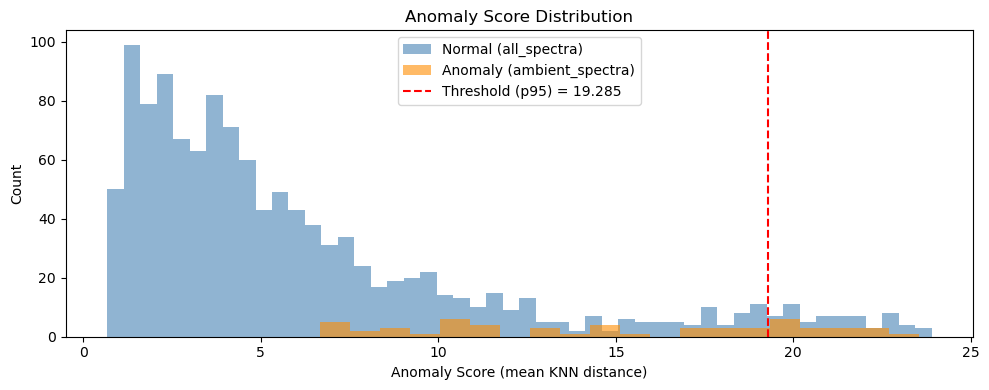

In [65]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot score distributions for both classes
ax.hist(scores_normal,  bins=50, alpha=0.6, color='steelblue',  label='Normal (all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')

# Draw the decision threshold
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold (p{THRESHOLD_PERCENTILE}) = {threshold:.3f}')

ax.set_xlabel('Anomaly Score (mean KNN distance)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.show()

**Results:**

**Normal samples (blue)** — scores are concentrated between 0–10, peaking around 1–4. Most normal particles have close neighbors in the training set, meaning they cluster tightly together. The long tail up to ~25 represents rare/isolated polymer classes with few nearby neighbors.

**Anomaly samples (orange)** — scores are spread broadly from 0 to 25 with no clear peak. They are flat and scattered across the entire range, with some ambient samples scoring very low (near 0) and some very high (near 25).

**Threshold (red dashed line) at 19.285** — only ambient samples with scores above 19.285 get flagged as anomalies. Most orange bars fall below the threshold, meaning the model is **missing most of the ambient samples**.

**The core problem:** The two distributions **heavily overlap** between 0–19. The ambient samples don't score distinctly higher than normal ones — many of them look "normal" to the KNN model. This indicates that ambient spectra are not actually that far from the normal training data in Euclidean space.

**Things to try to improve separation:**
- Lower `THRESHOLD_PERCENTILE` (e.g. 50–75) to catch more anomalies, though this increases false positives
- Change `METRIC` to `'cosine'` — cosine distance measures the *shape* of the spectrum rather than magnitude, which may separate ambient better
- Increase `N_NEIGHBORS` — averaging over more neighbors can smooth out noise in the scores

## 8. Evaluate Performance

Predictions are made by comparing each sample's anomaly score against the threshold. Then standard classification metrics are used to measure how well the model separates normal from anomalous samples.

- **Label convention:** `0` = normal, `1` = anomaly
- **Precision** — of all samples flagged as anomalies, how many actually were?
- **Recall** — of all actual anomalies, how many did the model catch?
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank anomalies above normal samples (1.0 = perfect, 0.5 = random)

In [66]:
# Combine scores and true labels for evaluation
# 0 = normal, 1 = anomaly
all_scores = np.concatenate([scores_normal, scores_anomaly])
true_labels = np.concatenate([
    np.zeros(len(scores_normal)),   # normal samples labeled 0
    np.ones(len(scores_anomaly))    # anomaly samples labeled 1
])

# Predict: score above threshold → anomaly (1), otherwise normal (0)
pred_labels = (all_scores > threshold).astype(int)

# Compute ROC-AUC using raw scores (threshold-independent)
roc_auc = roc_auc_score(true_labels, all_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.8843

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96      1215
     Anomaly       0.21      0.29      0.24        55

    accuracy                           0.92      1270
   macro avg       0.59      0.62      0.60      1270
weighted avg       0.93      0.92      0.93      1270



## 9. Confusion Matrix

The confusion matrix shows the breakdown of correct and incorrect predictions:

|  | Predicted Normal | Predicted Anomaly |
|--|--|--|
| **Actually Normal** | True Negative (TN) | False Positive (FP) |
| **Actually Anomaly** | False Negative (FN) | True Positive (TP) |

For anomaly detection, **False Negatives (FN)** are the most costly — these are real anomalies the model missed.

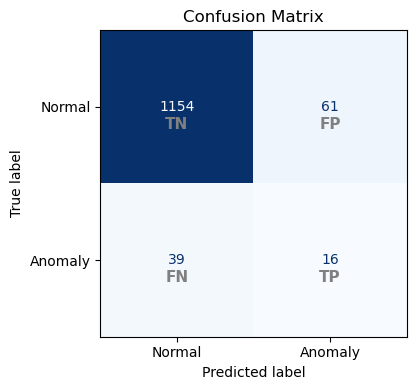

In [67]:
# Compute and display the confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — kNN'")

# Label each cell with TP, TN, FP, FN
labels = [["TN", "FP"],
          ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"\n\n{labels[i][j]}", ha="center", va="center",
                fontsize=11, fontweight="bold", color="gray")

plt.tight_layout()
plt.show()

**Results:**

| Cell | Count | Meaning |
|------|-------|---------|
| **TN = 1154** | 1154 normal samples correctly identified as normal | The model is very good at recognizing normal particles |
| **FP = 61** | 61 normal samples incorrectly flagged as anomalies | These are false alarms — normal particles the model was uncertain about |
| **FN = 39** | 39 ambient samples incorrectly classified as normal | The model **missed** these anomalies entirely |
| **TP = 16** | 16 ambient samples correctly caught as anomalies | Out of 55 ambient samples, only 16 were detected |

**What this tells you about the model's performance:**

- **The model is struggling to detect anomalies.** Out of 55 ambient samples, it only caught 16 (29% recall) and missed 39. This confirms what the score distribution plot showed — most ambient samples score similarly to normal ones.
- **The model is biased toward calling everything "normal."** It was trained only on normal data, so it naturally scores most things as normal.
- **The 61 false positives** come from rare/isolated polymer classes in `all_spectra` that have high anomaly scores, pushing them past the threshold.

**To improve TP and reduce FN, try:**
- Lowering `THRESHOLD_PERCENTILE` (e.g. 50) — the most direct fix
- Switching `METRIC` to `'cosine'` — may better separate ambient spectra by shape rather than magnitude

## 10. ROC Curve

The ROC curve plots the **True Positive Rate** (anomalies correctly caught) against the **False Positive Rate** (normal samples incorrectly flagged) across all possible thresholds.

- A curve hugging the top-left corner = excellent model
- A diagonal line = random guessing (AUC = 0.5)

This is useful because it shows performance independent of the threshold you chose.

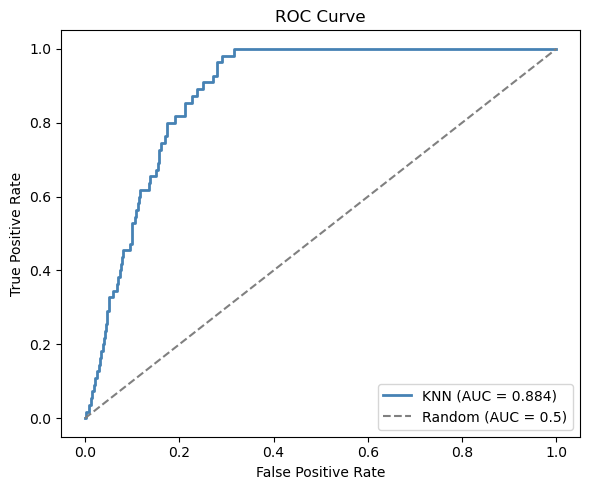

In [68]:
# Compute the ROC curve across all thresholds
fpr, tpr, _ = roc_curve(true_labels, all_scores)

fig, ax = plt.subplots(figsize=(6, 5))

# Plot the ROC curve
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'KNN (AUC = {roc_auc:.3f})')

# Plot the random baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()